## Time to get your hands dirty. Your first neural network; pick your favourite.


For the last coding assignment, you'll need to implement a neural network. We'll look at a relatively simple binary classification problem. Here below are three options; completing one of them for the exam is enough

### Tasks:

1. Remember: scale your data appropriately

2. Decide on a testing strategy (a simple test/train split? a CV strategy? set a test set aside to be looked at at the very end?)

2. Decide your optimization metric.

3. Write down your network architecture. You can start from a fully connected, multi-layer perceptron (and then explore)

4. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the MPL classifier implemented in scikit-learn. This is an opportunity to pick the one you're most interested in learning. 

5. Optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best.  Do your best now to optimize the network architecture. Be creative!

6. Report on the perfomance of the network on the test set; report other metrics that have not been optimized.


### A few tips:

- In scikit-learn, remember that you can utilize all availables cores on your machine with `n_jobs=-1`. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
- If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
- On cross validation, for scikit learn we've seen how to use `GridSearchCV` already. For Tensorflow, there's a really cool tool called [Tensorboard](https://www.tensorflow.org/tensorboard)

### Datasets:
**Galaxies vs quasars (but with neural networks)** Go back to our SDSS data we've used in Lecture 19. We had color differences, and the task was to classifty quasars vs galaxies. Repeat that task with a neural network.

## Time to get your hands dirty. Galaxies vs quasars with neural networks.

Let's go back to our galaxy vs quasar data we've used in a previous exercise. 

1. Read in SDSS galaxy color data from `solutions/galaxyquasar.csv`. Create arrays for the $(u-g)$, $(g-r)$, $(r-i)$, and $(i-z)$ colors. Also create an array with the class labels where galaxy=$0$ and quasar=$1$. 

2. Now we're going to fit a neural network classifier. First, scale your data appropriately and do a 30% train/test split.

3. Now train the classifier. Use one the package among those we've seen. These include Tensorflow via keras, pytorch, and the [multilayer perceptron classifier](sklearn.neural_network.MLPClassifier) implemented in scikit-learn. My solution uses the latter, but this is an opportunity to pick the one you're most interested in learning. 

3. Start from a network architecture with a single hidden layer with 5 neurons, using the `adam` solver, the `relu` activation function, and a learninig rate of `0.001`. Plot the resulting ROC curve. 

4. Now let's optimize the hyperparameters of your network. Explore different hyperparameters and see what fits the data best.  Do your best now to optimize the network architecture. Be creative!

5. Is your best result comparable with the simpler classifiers we've seen before? Do we need deep learning here? If yes, which features are captured best?


A few tips:

- In scikit-learn, remember that you can utilize all availables cores on your machine with `n_jobs=-1`. Print out the classification score for the training data, and the best parameters obtained by the cross validation.
- If it takes too long, run the hyperparameter optimization on a subset of the training set. Then retrain the full network using the best hyperparameters only.
- On cross validation, for scikit learn we've seen how to use `GridSearchCV` already. For Tensorflow, there's a really cool tool called [Tensorboard](https://www.tensorflow.org/tensorboard)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [3]:
u_g = (data['u'] - data['g']).to_numpy()
g_r = (data['g'] - data['r']).to_numpy()
r_i = (data['r'] - data['i']).to_numpy()
i_z = (data['i'] - data['z']).to_numpy()
labels = data['class'].map({'GALAXY': 0, 'QSO': 1}).to_numpy()

X = np.column_stack([u_g, g_r, r_i, i_z])
X_scaled = (X - X.mean(axis=0)) / X.std(axis=0)
y = labels

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=0.7, test_size=0.3, random_state=42)

Let's train a classifier! I chose Tensorflow:

In [4]:
import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import roc_curve as ROC
from astroML.utils import completeness_contamination

In [31]:
model = keras.Sequential([
    keras.layers.Dense(5, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid'),
])

In [32]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train)

y_prob = model.predict(X_test)
y_pred = (y_prob > 0.5).astype(int).flatten()

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9187 - loss: 0.3224
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 813us/step


Completeness: 0.9449074074074074
Contamination: 0.06718464351005485
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9823 - loss: 0.1224
Accuracy: 0.9822666645050049
Loss: 0.12241499871015549


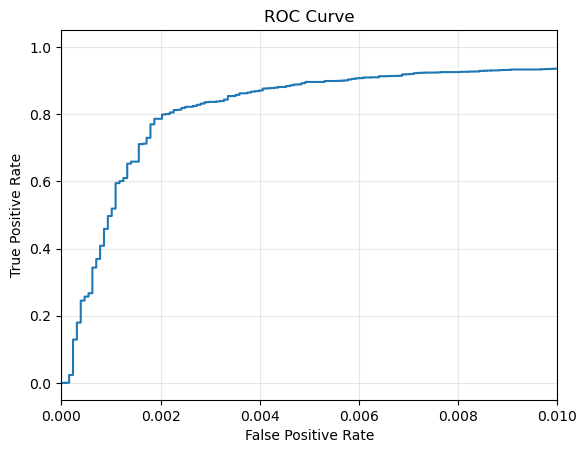

In [33]:
fpr, tpr, thresholds = ROC(y_test, y_prob)

compl, cont = completeness_contamination(y_test, y_pred)

plt.plot(fpr, tpr)
plt.xlim(0, 0.01)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(alpha=0.3)

print("Completeness:", compl)
print("Contamination:", cont)
loss, accuracy = model.evaluate(X_test, y_test)
print('Accuracy:', accuracy)
print('Loss:', loss)

ATTENZIONE 
vedo effettivamente il risultato


Completeness is already better than the one we obtained last time with GMMBayes (~0.93), even though contamination is a bit higher. We can try to optimize the hyperparameters of our network using Tensorboard:

In [11]:
import datetime
from tensorboard.plugins.hparams import api as hp

In [12]:
%load_ext tensorboard

In [13]:
HP_NUM_UNITS = hp.HParam('num_units', hp.Discrete([2, 4, 6, 8, 10]))
HP_LRATE = hp.HParam('learning_rate', hp.Discrete([0.001, 0.01, 0.1]))
HP_OPTIMIZER = hp.HParam('optimizer', hp.Discrete(['adam', 'sgd']))

METRIC_ACCURACY = 'accuracy'

with tf.summary.create_file_writer('logs/hparam_tuning').as_default():
  hp.hparams_config(
    hparams=[HP_NUM_UNITS, HP_LRATE, HP_OPTIMIZER],
    metrics=[hp.Metric(METRIC_ACCURACY, display_name='Accuracy')],
  )

In [14]:
def train_test_model(hparams):
    model = tf.keras.models.Sequential([
    keras.layers.Dense(hparams[HP_NUM_UNITS], activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
    ])

    if hparams[HP_OPTIMIZER] == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=hparams[HP_LRATE])
    elif hparams[HP_OPTIMIZER] == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=hparams[HP_LRATE])

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=1) # Run with 1 epoch to speed things up for demo purposes
    _, accuracy = model.evaluate(X_test, y_test)
    return accuracy

In [15]:
def run(run_dir, hparams):
  with tf.summary.create_file_writer(run_dir).as_default():
    hp.hparams(hparams)  # record the values used in this trial
    accuracy = train_test_model(hparams)
    tf.summary.scalar(METRIC_ACCURACY, accuracy, step=1)

In [16]:
session_num = 0

for num_units in HP_NUM_UNITS.domain.values:
  for learning_rate in HP_LRATE.domain.values:
    for optimizer in HP_OPTIMIZER.domain.values:
      hparams = {
          HP_NUM_UNITS: num_units,
          HP_LRATE: learning_rate,
          HP_OPTIMIZER: optimizer,
      }
      run_name = "run-%d" % session_num
      print('--- Starting trial: %s' % run_name)
      print({h.name: hparams[h] for h in hparams})
      run('logs/hparam_tuning/' + run_name, hparams)
      session_num += 1

--- Starting trial: run-0
{'num_units': 2, 'learning_rate': 0.001, 'optimizer': 'adam'}
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9073 - loss: 0.3692
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9545 - loss: 0.2108
--- Starting trial: run-1
{'num_units': 2, 'learning_rate': 0.001, 'optimizer': 'sgd'}
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8084 - loss: 0.6400
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8845 - loss: 0.5621
--- Starting trial: run-2
{'num_units': 2, 'learning_rate': 0.01, 'optimizer': 'adam'}
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9439 - loss: 0.1555
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9759 - loss: 0.0979
--- Starting trial: run-3
{'num_units': 2, 'learning_rate': 0.01, 'optimizer': 'sgd'}
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8587 - loss: 0.3155
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8541 - loss: 0.2415
--- Starting trial: run-4
{'num_units': 2, '

ATTENZIONE vedo risultati a ogni run

The best combination of hyperparameters seems to be the one from run 22, with:
- num_units = 8
- learning_rate = 0.1
- optimizer = adam

In [17]:
best_model = tf.keras.models.Sequential([
    keras.layers.Dense(4, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [18]:
best_optimizer = keras.optimizers.Adam(learning_rate=0.01)
best_model.compile(optimizer=best_optimizer, loss='binary_crossentropy', metrics=['accuracy'])
best_model.fit(X_train, y_train)

y_prob_best = best_model.predict(X_test)
y_pred_best = (y_prob_best > 0.5).astype(int).flatten()

1094/1094 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9649 - loss: 0.1270
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step


Completeness: 0.9561234329797492
Contamination: 0.09369287020109689
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9803 - loss: 0.0775
Accuracy: 0.9802666902542114
Loss: 0.07750669866800308


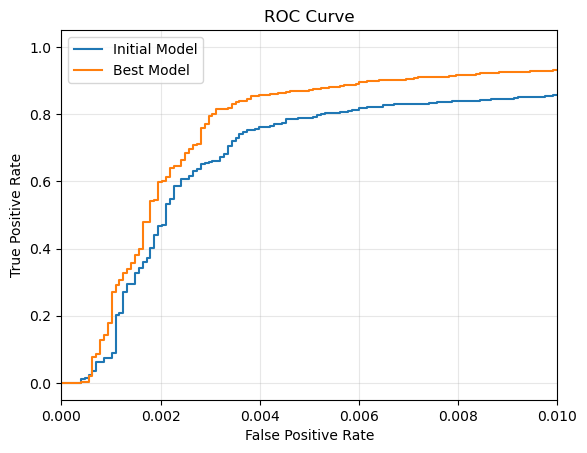

In [26]:
fpr_best, tpr_best, thresholds_best = ROC(y_test, y_prob_best)
fpr, tpr, thresholds = ROC(y_test, y_prob)

compl_best, cont_best = completeness_contamination(y_test, y_pred_best)

plt.plot(fpr, tpr, label='Initial Model')
plt.plot(fpr_best, tpr_best, label='Best Model')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim(0, 0.01)
plt.legend()
plt.grid(alpha=0.3)

print("Completeness:", compl_best)
print("Contamination:", cont_best)
loss, accuracy = best_model.evaluate(X_test, y_test)
print('Accuracy:', accuracy)
print('Loss:', loss)

ATTENZIONE

It seems that optimizing the hyperparameters did not lead to a significant improvement in our classifier, suggesting that we don't actually need deep learning for solving this problem.